# Model Training

### Data and Evaluate Functions for the Models

In [ ]:
import pandas as pd
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

results = []

def top_confusions(cm, labels, top_n=5):

    pairs = []
    for i in range(len(labels)):
        for j in range(len(labels)):
            if i == j:
                continue
            c = cm[i, j]
            if c > 0:
                pairs.append((labels[i], labels[j], int(c)))
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:top_n]

def confusions_to_df(confs, model_name):

    if not confs:
        return pd.DataFrame(columns=["model", "true", "pred", "count"])
    return pd.DataFrame(confs, columns=["true", "pred", "count"]).assign(model=model_name)[
        ["model", "true", "pred", "count"]
    ]

def evaluate_model(model, model_name: str, plot: bool = True, top_n_confusions: int = 5):
    
    # train time
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time_s = time.perf_counter() - t0

    # predict time
    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_time_s = time.perf_counter() - t0
    predict_ms_per_sample = (predict_time_s / len(X_test)) * 1000

    # metrics 
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

    print(f"{model_name}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"F1: {f1_macro:.4f}")
    print(f"Train time: {train_time_s:.4f} s")
    print(f"Predict time: {predict_time_s:.4f} s  ({predict_ms_per_sample:.4f} ms/sample)")

    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred))

    # most confused classes
    confs = top_confusions(cm, labels_sorted, top_n=top_n_confusions)
    print(f"\nTop-{top_n_confusions} most confused gesture pair (true -> pred):")
    if len(confs) == 0:
        print("No confusions (all predictions were true).")
    else:
        for t, p, c in confs:
            print(f"- {t} -> {p}: {c}")

    # plot
    if plot:
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            cm,
            annot=True, fmt="d",
            cmap="Blues",
            xticklabels=labels_sorted,
            yticklabels=labels_sorted
        )
        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "train_time_s": train_time_s,
        "predict_ms_per_sample": predict_ms_per_sample,
        "cm": cm,
        "top_confusions": confs
    }

### Model 1: Random Forest

RandomForest
Accuracy: 98.41%
F1 (macro): 0.9840
Train time: 0.9140 s
Predict time: 0.0105 s  (0.0238 ms/sample)

Classification report:

              precision    recall  f1-score   support

     approve       1.00      1.00      1.00        48
 dissapprove       0.96      1.00      0.98        46
   fingergun       1.00      1.00      1.00        55
 koreanheart       1.00      0.98      0.99        47
    mammamia       0.98      1.00      0.99        50
          ok       0.98      0.94      0.96        49
       peace       1.00      1.00      1.00        44
   rocknroll       0.98      0.98      0.98        50
        stop       0.96      0.96      0.96        50

    accuracy                           0.98       439
   macro avg       0.98      0.98      0.98       439
weighted avg       0.98      0.98      0.98       439


Top-5 most confused gesture pair (true -> pred):
- ok -> stop: 2
- koreanheart -> mammamia: 1
- ok -> dissapprove: 1
- rocknroll -> dissapprove: 1
- stop ->

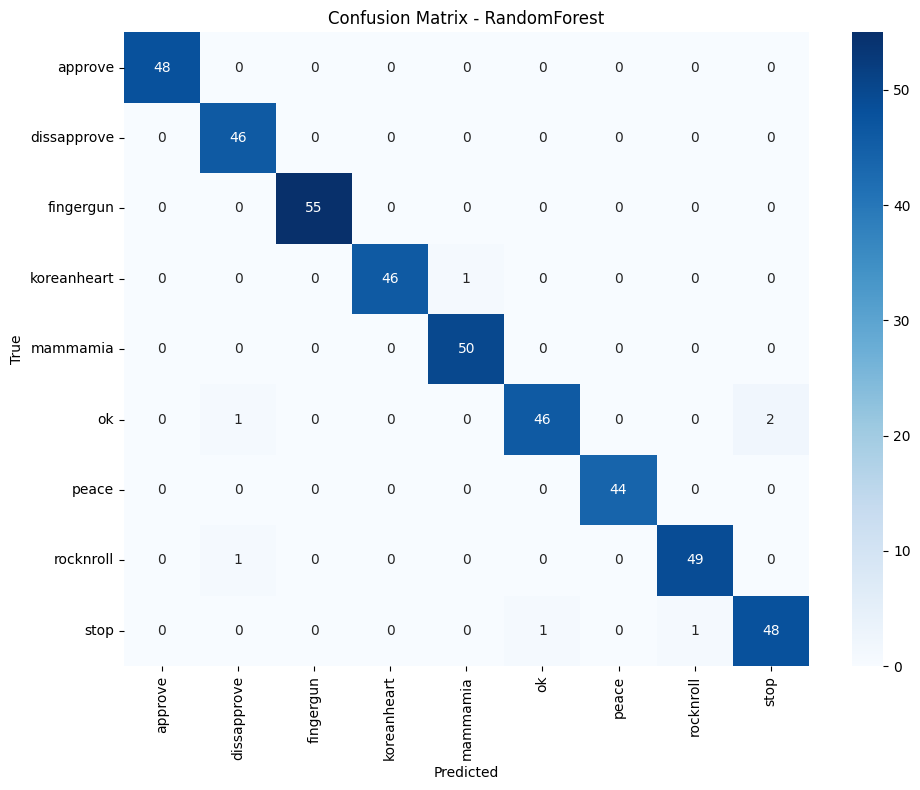

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
res_rf = evaluate_model(rf, "RandomForest")
results.append(res_rf)

### Model 2: SVM

SVM_RBF
Accuracy: 100.00%
F1 (macro): 1.0000
Train time: 0.1064 s
Predict time: 0.0104 s  (0.0237 ms/sample)

Classification report:

              precision    recall  f1-score   support

     approve       1.00      1.00      1.00        48
 dissapprove       1.00      1.00      1.00        46
   fingergun       1.00      1.00      1.00        55
 koreanheart       1.00      1.00      1.00        47
    mammamia       1.00      1.00      1.00        50
          ok       1.00      1.00      1.00        49
       peace       1.00      1.00      1.00        44
   rocknroll       1.00      1.00      1.00        50
        stop       1.00      1.00      1.00        50

    accuracy                           1.00       439
   macro avg       1.00      1.00      1.00       439
weighted avg       1.00      1.00      1.00       439


Top-5 most confused gesture pair (true -> pred):
No confusions (all predictions were true).


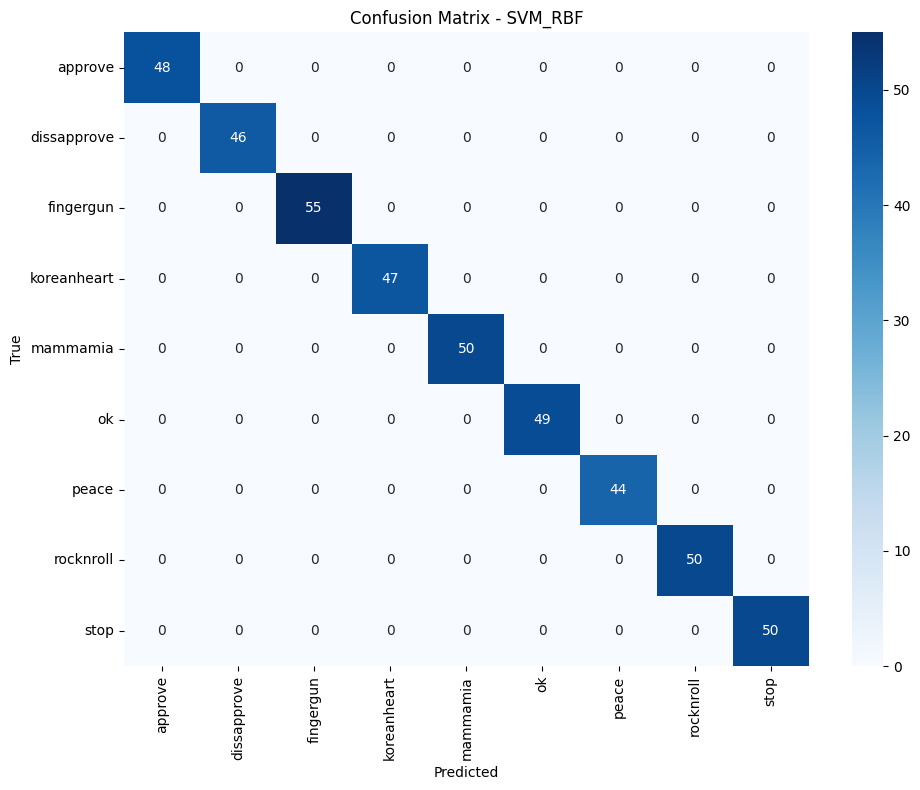

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=RANDOM_STATE))
])

res_svm = evaluate_model(svm, "SVM_RBF")
results.append(res_svm)


### Model 3: KNN

KNN
Accuracy: 96.81%
F1 (macro): 0.9685
Train time: 0.0031 s
Predict time: 0.0061 s  (0.0138 ms/sample)

Classification report:

              precision    recall  f1-score   support

     approve       1.00      0.98      0.99        48
 dissapprove       0.96      1.00      0.98        46
   fingergun       0.96      1.00      0.98        55
 koreanheart       1.00      1.00      1.00        47
    mammamia       1.00      0.98      0.99        50
          ok       0.88      0.94      0.91        49
       peace       1.00      1.00      1.00        44
   rocknroll       0.98      0.96      0.97        50
        stop       0.93      0.86      0.90        50

    accuracy                           0.97       439
   macro avg       0.97      0.97      0.97       439
weighted avg       0.97      0.97      0.97       439


Top-5 most confused gesture pair (true -> pred):
- stop -> ok: 6
- ok -> stop: 3
- rocknroll -> dissapprove: 2
- approve -> fingergun: 1
- mammamia -> fingergun: 1


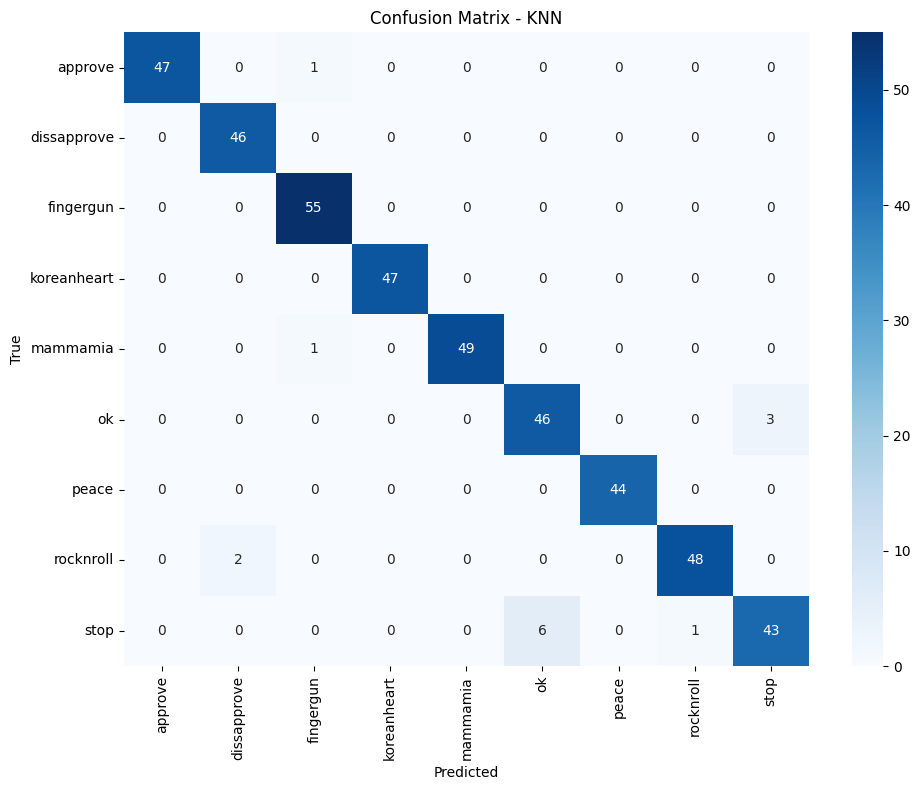

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7, weights="distance"))
])

res_knn = evaluate_model(knn, "KNN", plot=True)
results.append(res_knn)


### Comparision Between the Models

In [35]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df["accuracy_%"] = (results_df["accuracy"] * 100).round(2)
results_df["F1"] = results_df["f1_macro"].round(4)
results_df["train_time_s"] = results_df["train_time_s"].round(4)
results_df["predict_ms_per_sample"] = results_df["predict_ms_per_sample"].round(4)

final_df = results_df[[
    "model", "accuracy_%", "F1", "train_time_s", "predict_ms_per_sample"
]].sort_values(by="F1", ascending=False)

display(final_df)

,model,accuracy_%,F1,train_time_s,predict_ms_per_sample
1,SVM_RBF,100.00,1.0000,0.1064,0.0237
0,RandomForest,98.41,0.9840,0.9140,0.0238
2,KNN,96.81,0.9685,0.0031,0.0138


### Most Confused Gestures

In [37]:
confusion_tables = []

for r in results:
    confusion_tables.append(confusions_to_df(r["top_confusions"], r["model"]))

all_confusions_df = pd.concat(confusion_tables, ignore_index=True)

if len(all_confusions_df) == 0:
    print("Hiç karışma yok (tüm modellerde tahminler doğru veya top_n içinde hata yok).")
else:

    all_confusions_df = all_confusions_df.sort_values(["count"], ascending=False)
    display(all_confusions_df.head(30))

,model,true,pred,count
5,KNN,stop,ok,6
6,KNN,ok,stop,3
0,RandomForest,ok,stop,2
7,KNN,rocknroll,dissapprove,2
1,RandomForest,koreanheart,mammamia,1
2,RandomForest,ok,dissapprove,1
3,RandomForest,rocknroll,dissapprove,1
4,RandomForest,stop,ok,1
8,KNN,approve,fingergun,1
9,KNN,mammamia,fingergun,1


### Saving SVM for Demo

In [39]:
import joblib
joblib.dump(svm, "svm_gesture_model.pkl")
print("Saved: svm_gesture_model.pkl")

Saved: svm_gesture_model.pkl
